In [ ]:
pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 38.5 MB/s eta 0:00:00


In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Draw

In [ ]:
Smiles_List = [
"ClC1=NC2=C(C(N3CCOCC3)=N1)N=C(N2C)CN(C)C4=NC=C(C=N4)C(NC5=CC=CC(C)=C5)=O",
"ClC1=NC2=C(C(N3CCOCC3)=N1)N=C(N2C)CN(C)C4=NC=C(C=N4)C(NC5=CC=CC(F)=C5)=O",
"ClC1=NC2=C(C(N3CCOCC3)=N1)N=C(N2C)CN(C)C4=NC=C(C=N4)C(NC5=CC=C(C)C=C5)=O",
"ClC1=NC2=C(C(N3CCOCC3)=N1)N=C(N2C)CN(C)C4=NC=C(C=N4)C(NC5=CC=C(F)C=C5)=O",
"ClC1=NC2=C(C(N3CCOCC3)=N1)N=C(N2C)CN(C)C4=NC=C(C=N4)C(NC5=CC=CC=C5)=O",
"ClC1=NC2=C(C(N3CCOCC3)=N1)N=C(N2C)CN(C)C4=NC=C(C=N4)C(NC5=CC=C(OC)C=C5)=O",
"ClC1=NC2=C(C(N3CCOCC3)=N1)N=C(N2C)CN(C)C4=NC=C(C=N4)C(NC5=CC=CC(OC)=C5)=O",
"ClC1=NC2=C(C(N3CCOCC3)=N1)N=C(N2C)CN(C)C4=NC=C(C=N4)C(NC5=CC=C(Cl)C=C5)=O",
"ClC1=NC2=C(C(N3CCOCC3)=N1)N=C(N2C)CN(C)C4=NC=C(C=N4)C(NC5=CC=NC=C5)=O",
"ClC1=NC2=C(C(N3CCOCC3)=N1)N=C(N2C)CN(C)C4=NC=C(C=N4)C(NC5=CC=CC=N5)=O"
]
names = [f"Mol_{i+1}" for i in range(20) ]

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw

In [ ]:
mols = []
for smi in Smiles_List:
    mol = Chem.MolFromSmiles(smi)
    mols.append(mol)


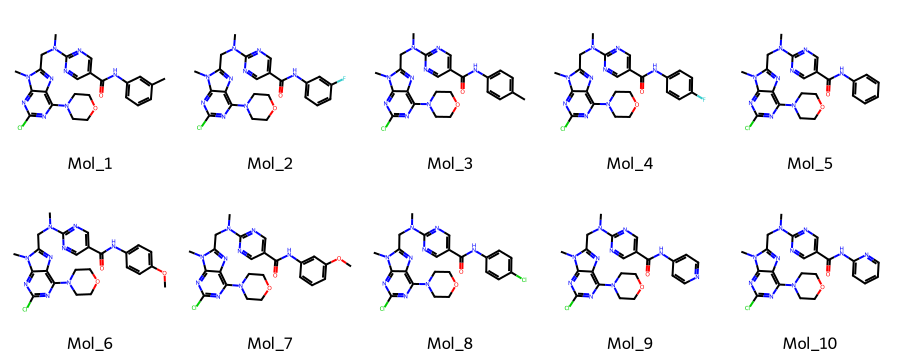

In [ ]:
Draw.MolsToGridImage(mols, molsPerRow=5, subImgSize=(180,180), legends=names)

In [ ]:
from rdkit.Chem import Descriptors, Lipinski
import pandas as pd

In [ ]:
data = []
for name, mol in zip(names, mols):
   mw = Descriptors.MolWt(mol)
   logp = Descriptors.MolLogP(mol)
   hba = Lipinski.NumHAcceptors(mol)
   hbd = Lipinski.NumHDonors(mol)
   tpsa = Descriptors.TPSA(mol)
   rules = "PASS" if mw<=500 and logp<=5 and hba<=10 and hbd<=5 else "FAIL"
   data.append([name, round(mw, 1), round(logp, 2), round(tpsa, 2), hba, hbd, rules])
df = pd.DataFrame(data, columns=["NAME", "MW", "LogP","TPSA", "HBA", "HBD", "Lipinski"])
display(df)

,NAME,MW,LogP,TPSA,HBA,HBD,Lipinski
0,Mol_1,508.0,2.84,114.19,9,1,FAIL
1,Mol_2,511.9,2.67,114.19,9,1,FAIL
2,Mol_3,508.0,2.84,114.19,9,1,FAIL
3,Mol_4,511.9,2.67,114.19,9,1,FAIL
4,Mol_5,494.0,2.53,114.19,9,1,PASS
5,Mol_6,524.0,2.54,123.42,10,1,FAIL
6,Mol_7,524.0,2.54,123.42,10,1,FAIL
7,Mol_8,528.4,3.19,114.19,9,1,FAIL
8,Mol_9,494.9,1.93,127.08,10,1,PASS
9,Mol_10,494.9,1.93,127.08,10,1,PASS


In [ ]:
from rdkit.Chem import AllChem

# Make fingerprint for each molecule
fps = [AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=2048) for m in mols]

# Show first molecule fingerprint as 0/1 bits (first 50 bits only)
print("Mol_1 fingerprint (first 50 bits):")
print(list(fps[0].ToBitString()[:50]))

print("\nTotal length:", len(fps[0].ToBitString()))
print("Total molecules fingerprinted:", len(fps))

Mol_1 fingerprint (first 50 bits):
['0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0']

Total length: 2048
Total molecules fingerprinted: 10


,Mol_1,Mol_2,Mol_3,Mol_4,Mol_5,Mol_6,Mol_7,Mol_8,Mol_9,Mol_10
Mol_1,1.00,0.85,0.84,0.78,0.85,0.76,0.83,0.80,0.79,0.74
Mol_2,0.85,1.00,0.78,0.84,0.84,0.75,0.82,0.79,0.78,0.73
Mol_3,0.84,0.78,1.00,0.87,0.87,0.85,0.76,0.90,0.86,0.76
Mol_4,0.78,0.84,0.87,1.00,0.86,0.84,0.77,0.88,0.85,0.75
Mol_5,0.85,0.84,0.87,0.86,1.00,0.83,0.81,0.88,0.87,0.82
Mol_6,0.76,0.75,0.85,0.84,0.83,1.00,0.84,0.86,0.82,0.73
Mol_7,0.83,0.82,0.76,0.77,0.81,0.84,1.00,0.77,0.76,0.72
Mol_8,0.80,0.79,0.90,0.88,0.88,0.86,0.77,1.00,0.87,0.79
Mol_9,0.79,0.78,0.86,0.85,0.87,0.82,0.76,0.87,1.00,0.78
Mol_10,0.74,0.73,0.76,0.75,0.82,0.73,0.72,0.79,0.78,1.00


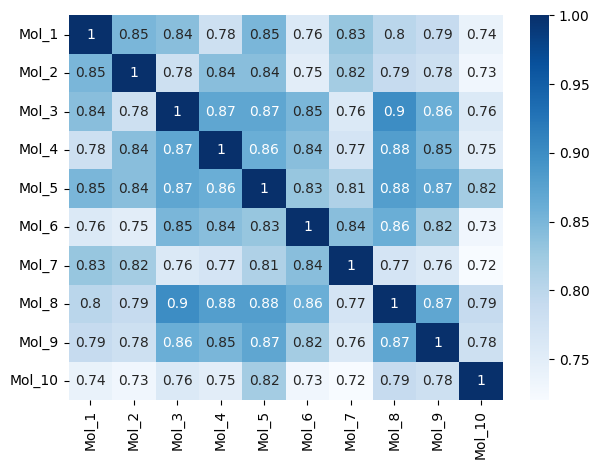

In [ ]:
from rdkit import DataStructs
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

n = len(fps)
sim_matrix = []
for i in range(n):
    row = []
    for j in range(n):
        sim = DataStructs.TanimotoSimilarity(fps[i], fps[j])
        row.append(round(sim, 2))
    sim_matrix.append(row)

# Ultimate fix - recreate matrix and names together
names = [f"Mol_{i+1}" for i in range(len(mols))]
n = len(fps)
sim_matrix = [[round(DataStructs.TanimotoSimilarity(fps[i], fps[j]),2) for j in range(n)] for i in range(n)]

sim_df = pd.DataFrame(sim_matrix, index=names, columns=names)
display(sim_df)

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
sns.heatmap(sim_df, annot=True, cmap="Blues")
plt.show()